# Step 4 — Probability Calibration

evaluate whether the model's predicted probabilities are reliable, then apply two calibration methods:
- **Platt Scaling** — fits a logistic regression on top of raw probabilities
- **Isotonic Regression** — fits a non-parametric monotonic function

Calibration is evaluated using:
- **Reliability diagram** (visual check)
- **Brier Score** — measures mean squared error of probability predictions (lower is better)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, classification_report

print('All imports successful!')

All imports successful!


In [2]:
# Load data and recreate splits
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')
df['target'] = (df['status_label'] == 'failed').astype(int)

train_df = df[df['fyear'] <= 2011]
val_df   = df[(df['fyear'] >= 2012) & (df['fyear'] <= 2014)]
test_df  = df[df['fyear'] >= 2015]

FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']

cat_idx = [FEATURES.index('Division')]

X_val  = val_df[FEATURES];  y_val  = val_df['target']
X_test = test_df[FEATURES]; y_test = test_df['target']

val_pool  = Pool(X_val,  y_val,  cat_features=cat_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_idx)

# Load trained model
model = CatBoostClassifier()
model.load_model('../model/catboost_bankruptcy.cbm')

# Raw probabilities
val_proba  = model.predict_proba(val_pool)[:, 1]
test_proba = model.predict_proba(test_pool)[:, 1]

print(f'Validation set: {len(y_val)} samples')
print(f'Test set:       {len(y_test)} samples')
print(f'Val  prob range: [{val_proba.min():.4f}, {val_proba.max():.4f}]')
print(f'Test prob range: [{test_proba.min():.4f}, {test_proba.max():.4f}]')

Validation set: 10473 samples
Test set:       12282 samples
Val  prob range: [0.0094, 0.8815]
Test prob range: [0.0112, 0.8875]


## Baseline Brier Score (uncalibrated)

In [3]:
brier_uncal = brier_score_loss(y_test, test_proba)
print(f'Brier Score (uncalibrated): {brier_uncal:.5f}')
print(f'AUC (uncalibrated):         {roc_auc_score(y_test, test_proba):.4f}')

Brier Score (uncalibrated): 0.11061
AUC (uncalibrated):         0.8241


## Fit Calibrators on Validation Set

In [4]:
# Platt Scaling (logistic regression on raw probabilities)
platt = LogisticRegression()
platt.fit(val_proba.reshape(-1, 1), y_val)
test_proba_platt = platt.predict_proba(test_proba.reshape(-1, 1))[:, 1]

# Isotonic Regression
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(val_proba, y_val)
test_proba_iso = iso.predict(test_proba)

brier_platt = brier_score_loss(y_test, test_proba_platt)
brier_iso   = brier_score_loss(y_test, test_proba_iso)

print(f'Brier Score — Uncalibrated:   {brier_uncal:.5f}')
print(f'Brier Score — Platt Scaling:  {brier_platt:.5f}')
print(f'Brier Score — Isotonic Reg.:  {brier_iso:.5f}')
print()
print(f'AUC — Platt:    {roc_auc_score(y_test, test_proba_platt):.4f}')
print(f'AUC — Isotonic: {roc_auc_score(y_test, test_proba_iso):.4f}')

Brier Score — Uncalibrated:   0.11061
Brier Score — Platt Scaling:  0.02332
Brier Score — Isotonic Reg.:  0.02473

AUC — Platt:    0.8241
AUC — Isotonic: 0.8246


## Reliability Diagrams

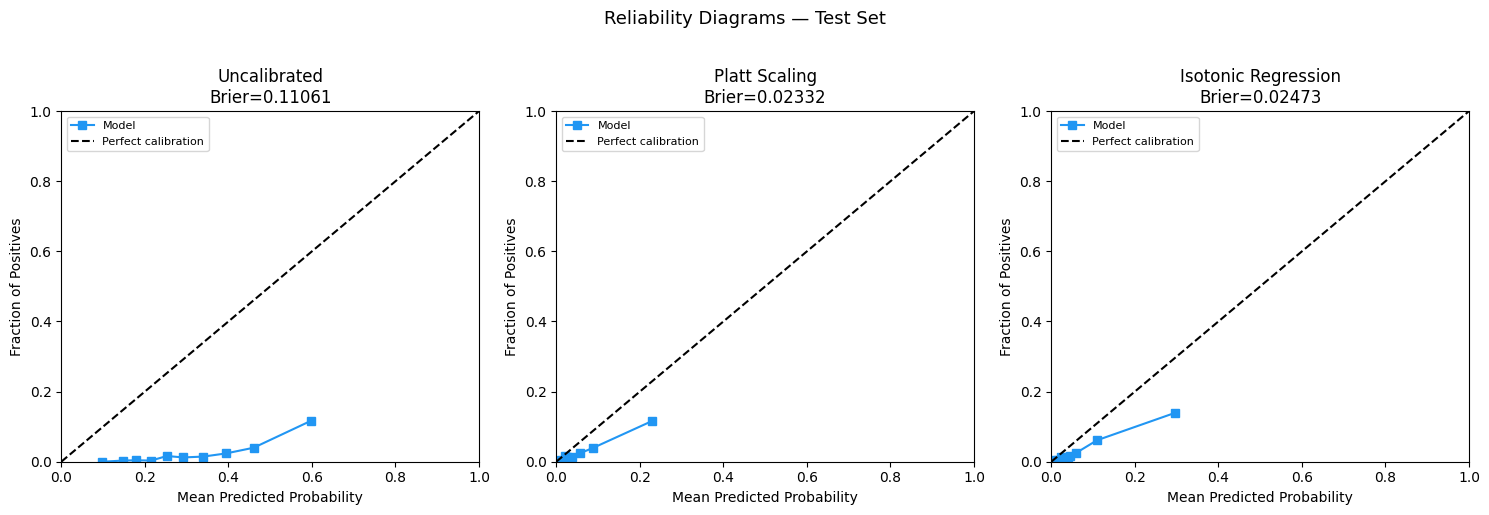

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    ('Uncalibrated',      test_proba,       f'Brier={brier_uncal:.5f}'),
    ('Platt Scaling',     test_proba_platt, f'Brier={brier_platt:.5f}'),
    ('Isotonic Regression', test_proba_iso, f'Brier={brier_iso:.5f}'),
]

for ax, (title, proba, brier_label) in zip(axes, configs):
    fraction_of_positives, mean_predicted = calibration_curve(
        y_test, proba, n_bins=10, strategy='quantile'
    )
    ax.plot(mean_predicted, fraction_of_positives, 's-', color='#2196F3', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{title}\n{brier_label}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Reliability Diagrams — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Classification Performance After Calibration (threshold = 0.4)

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for label, proba in [('Uncalibrated', test_proba),
                      ('Platt Scaling', test_proba_platt),
                      ('Isotonic Regression', test_proba_iso)]:
    preds = (proba >= 0.4).astype(int)
    rows.append({
        'Approach':         label,
        'AUC':              round(roc_auc_score(y_test, proba), 4),
        'Brier Score':      round(brier_score_loss(y_test, proba), 5),
        'Failed Recall':    round(recall_score(y_test, preds, pos_label=1), 3),
        'Failed Precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'Failed F1':        round(f1_score(y_test, preds, pos_label=1, zero_division=0), 3),
    })

summary = pd.DataFrame(rows).set_index('Approach')
print(summary.to_string())

                        AUC  Brier Score  Failed Recall  Failed Precision  Failed F1
Approach                                                                            
Uncalibrated         0.8241      0.11061          0.704             0.069      0.125
Platt Scaling        0.8241      0.02332          0.132             0.250      0.173
Isotonic Regression  0.8246      0.02473          0.153             0.242      0.188


## Save Calibrators

In [10]:
joblib.dump(platt, '../model/platt_calibrator.joblib')
joblib.dump(iso,   '../model/isotonic_calibrator.joblib')

# Update metadata with best calibrator choice
best_cal = 'platt' if brier_platt <= brier_iso else 'isotonic'
meta = joblib.load('../model/app_metadata.joblib')
meta['best_calibrator'] = best_cal
meta['brier_uncalibrated'] = round(brier_uncal, 5)
meta['brier_platt']        = round(brier_platt, 5)
meta['brier_isotonic']     = round(brier_iso, 5)
joblib.dump(meta, '../model/app_metadata.joblib')

print(f'Calibrators saved.')
print(f'Best calibrator: {best_cal}')

Calibrators saved.
Best calibrator: platt
